# Project 2: Exploratory Data Analysis (EDA)
**Goal:** Analyze the dataset to understand patterns, trends, and distributions.

**Dataset:** E-commerce orders — 1,200 rows, 14 columns  
**Date Range:** January 2023 – June 2025

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1200, 16)
Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month', 'Year']


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01,2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02,2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05,2025


## 3. Basic Statistics (Mean, Median, Count)

In [3]:
print('=== Descriptive Statistics ===')
desc = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe().round(2)
print(desc)

print('\n=== Key Metrics ===')
print(f"Total Orders      : {len(df):,}")
print(f"Total Revenue     : ${df['TotalPrice'].sum():,.2f}")
print(f"Mean Order Value  : ${df['TotalPrice'].mean():,.2f}")
print(f"Median Order Value: ${df['TotalPrice'].median():,.2f}")
print(f"Std Dev (Price)   : ${df['TotalPrice'].std():,.2f}")
print(f"Date Range        : {df['Date'].min().date()} to {df['Date'].max().date()}")

=== Descriptive Statistics ===
       Quantity  UnitPrice  ItemsInCart  TotalPrice
count   1200.00    1200.00      1200.00     1200.00
mean       2.95     356.41         5.48     1053.97
std        1.41     197.18         2.28      819.86
min        1.00      11.39         1.00       11.39
25%        2.00     186.06         4.00      410.52
50%        3.00     364.21         5.00      823.62
75%        4.00     521.57         7.00     1578.48
max        5.00     699.93        10.00     3456.40

=== Key Metrics ===
Total Orders      : 1,200
Total Revenue     : $1,264,761.96
Mean Order Value  : $1,053.97
Median Order Value: $823.62
Std Dev (Price)   : $819.86
Date Range        : 2023-01-01 to 2025-06-30


## 4. Missing Values & Data Quality

In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Duplicate Rows ===')
print(f"Duplicates: {df.duplicated().sum()}")

=== Missing Values ===
CouponCode    309
dtype: int64

=== Data Types ===
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
Month                   period[M]
Year                        int32
dtype: object

=== Duplicate Rows ===
Duplicates: 0


## 5. Distribution of TotalPrice

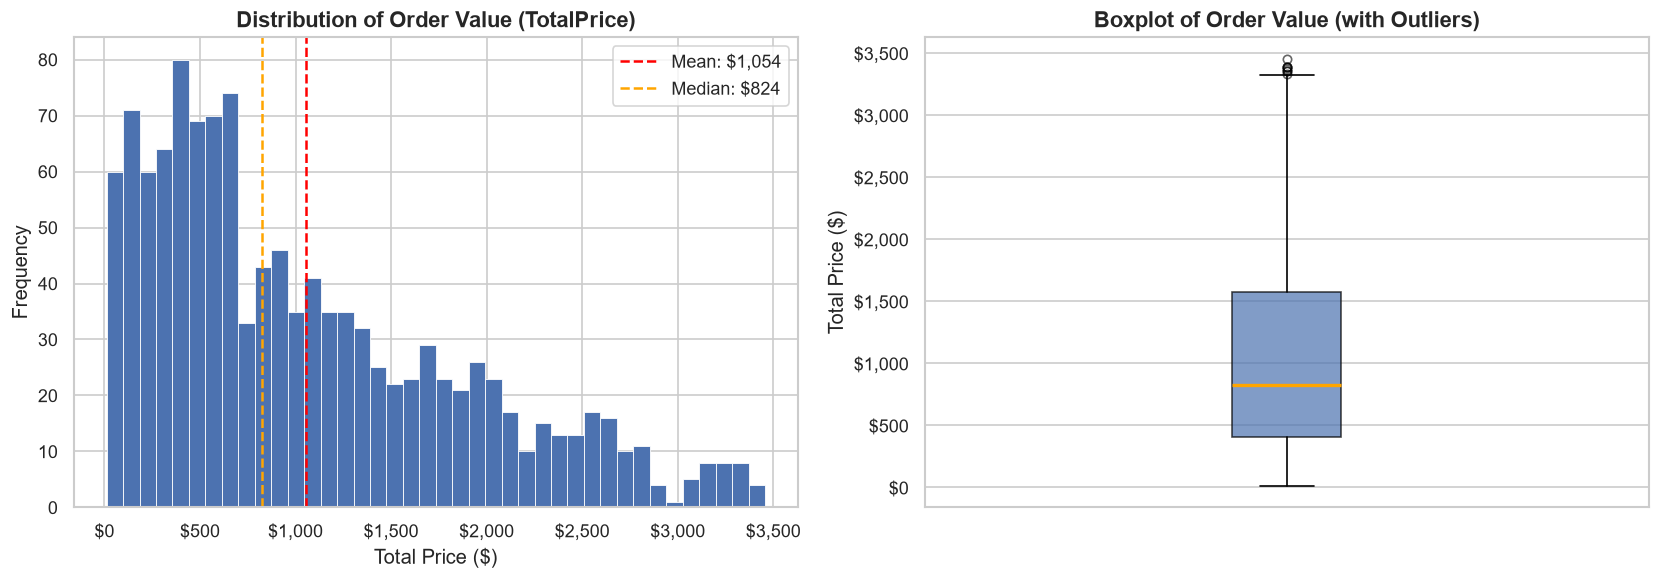

Chart saved: 01_price_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['TotalPrice'], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: ${df['TotalPrice'].mean():,.0f}")
axes[0].axvline(df['TotalPrice'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: ${df['TotalPrice'].median():,.0f}")
axes[0].set_title('Distribution of Order Value (TotalPrice)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Boxplot
axes[1].boxplot(df['TotalPrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='orange', linewidth=2),
                flierprops=dict(marker='o', color='red', markersize=5, alpha=0.6))
axes[1].set_title('Boxplot of Order Value (with Outliers)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Price ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('01_price_distribution.png', bbox_inches='tight')
plt.show()
print('Chart saved: 01_price_distribution.png')

## 6. Outlier Detection

In [6]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]

print(f'IQR Method — Lower bound: ${lower:,.2f} | Upper bound: ${upper:,.2f}')
print(f'Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of orders)')
print(f'Outlier TotalPrice range: ${outliers["TotalPrice"].min():,.2f} – ${outliers["TotalPrice"].max():,.2f}')
print('\nOutlier details:')
print(outliers[['OrderID', 'Date', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].to_string(index=False))

IQR Method — Lower bound: $-1,341.41 | Upper bound: $3,330.41
Number of outliers: 8 (0.7% of orders)
Outlier TotalPrice range: $3,334.00 – $3,456.40

Outlier details:
  OrderID       Date Product  Quantity  UnitPrice  TotalPrice
ORD200107 2023-03-27 Printer         5     670.75     3353.75
ORD200326 2024-07-01  Laptop         5     670.48     3352.40
ORD200328 2023-02-28  Tablet         5     674.04     3370.20
ORD200469 2023-11-26   Chair         5     676.98     3384.90
ORD200632 2023-05-02  Laptop         5     678.16     3390.80
ORD200789 2023-08-17  Tablet         5     691.28     3456.40
ORD201065 2023-10-30 Printer         5     666.80     3334.00
ORD201122 2023-06-07 Monitor         5     678.19     3390.95


## 7. Revenue by Product

         Total Revenue  Avg Order Value  Order Count
Product                                             
Chair        195620.11          1098.99          178
Printer      195612.61          1080.73          181
Laptop       192126.56          1110.56          173
Tablet       186568.95          1042.28          179
Monitor      175651.41          1077.62          163
Desk         167459.93           985.06          170
Phone        151722.39           972.58          156


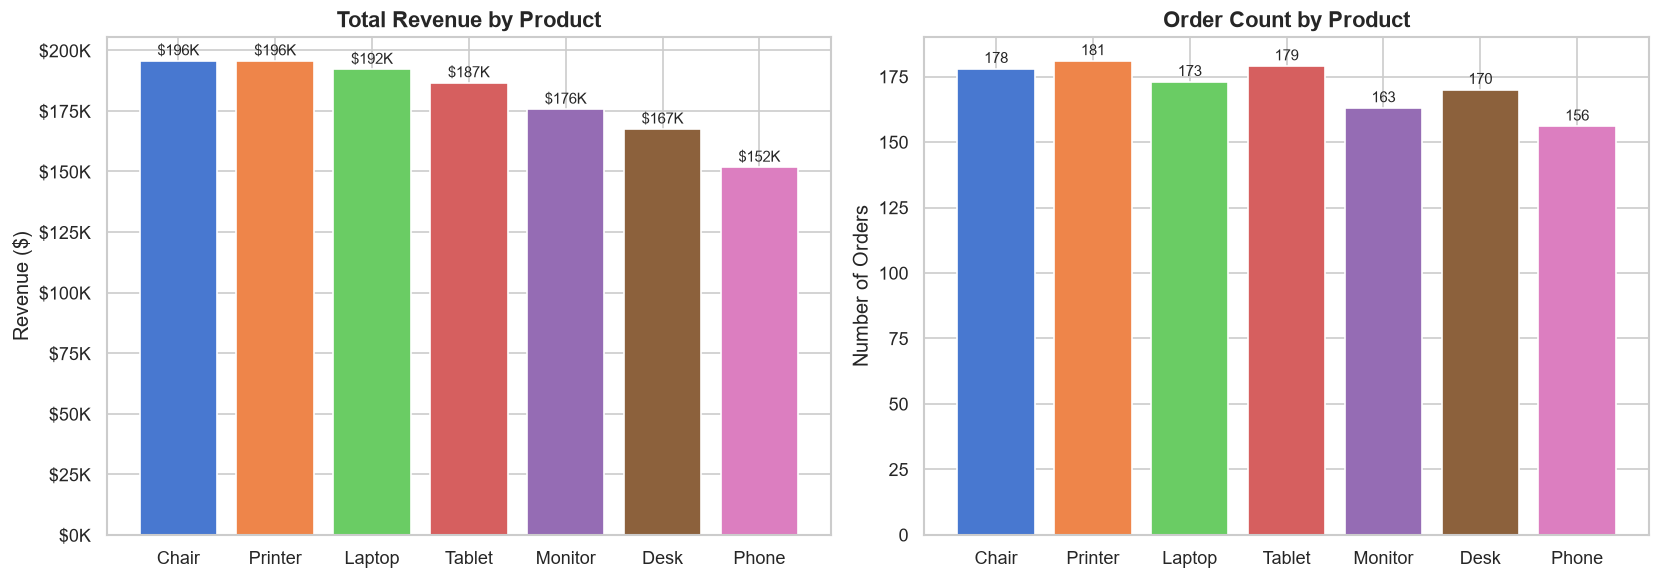

Chart saved: 02_revenue_by_product.png


In [7]:
prod_rev = df.groupby('Product')['TotalPrice'].agg(['sum', 'mean', 'count']).round(2)
prod_rev.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
prod_rev = prod_rev.sort_values('Total Revenue', ascending=False)
print(prod_rev)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('muted', len(prod_rev))

# Total revenue
bars = axes[0].bar(prod_rev.index, prod_rev['Total Revenue'], color=colors, edgecolor='white')
axes[0].set_title('Total Revenue by Product', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=9)

# Order count
bars2 = axes[1].bar(prod_rev.index, prod_rev['Order Count'], color=colors, edgecolor='white')
axes[1].set_title('Order Count by Product', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('02_revenue_by_product.png', bbox_inches='tight')
plt.show()
print('Chart saved: 02_revenue_by_product.png')

## 8. Monthly Revenue Trend

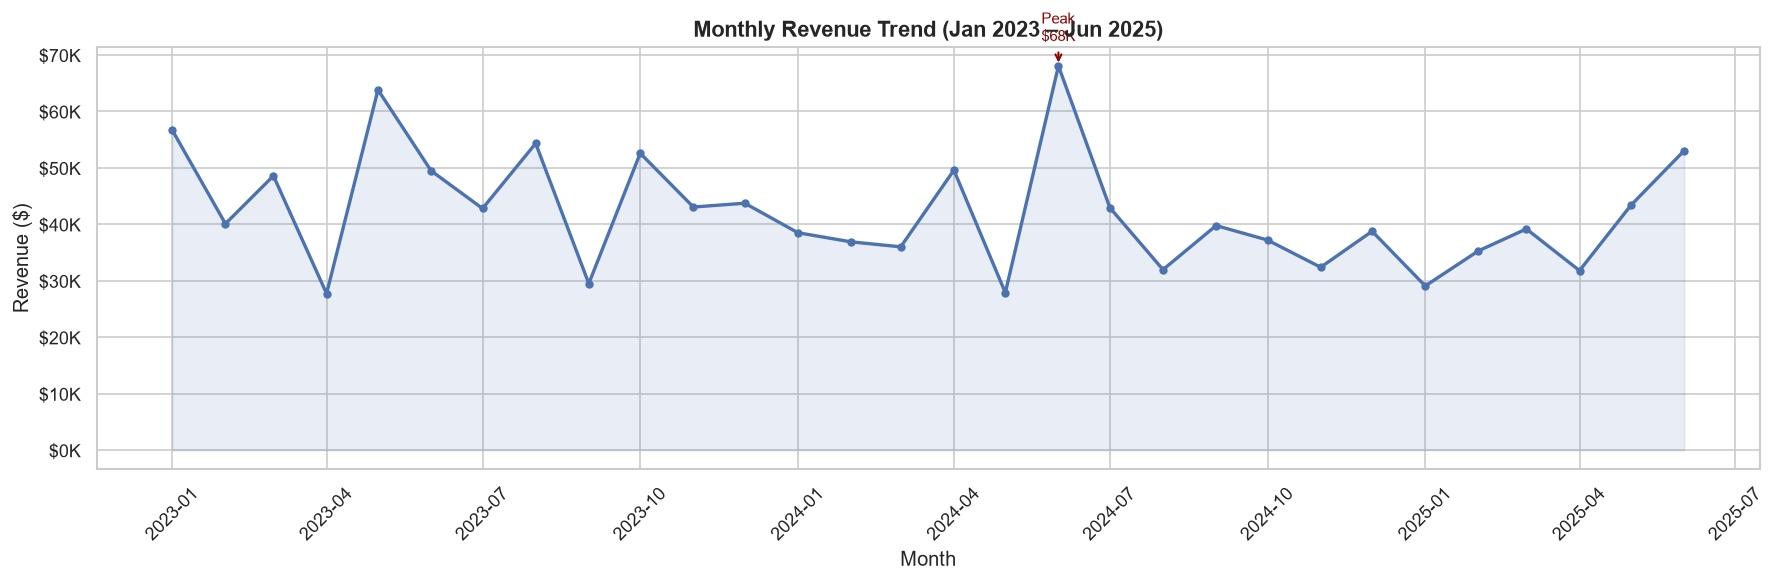

Chart saved: 03_monthly_trend.png

Revenue by Year:
  2023: $552,643.24
  2024: $480,235.87
  2025: $231,882.85


In [8]:
monthly = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(monthly['Month_dt'], monthly['TotalPrice'], color='#4C72B0', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['Month_dt'], monthly['TotalPrice'], alpha=0.12, color='#4C72B0')

# Mark peak
peak_idx = monthly['TotalPrice'].idxmax()
ax.annotate(f"Peak\n${monthly.loc[peak_idx,'TotalPrice']/1000:.0f}K",
            xy=(monthly.loc[peak_idx,'Month_dt'], monthly.loc[peak_idx,'TotalPrice']),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2))

ax.set_title('Monthly Revenue Trend (Jan 2023 – Jun 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('03_monthly_trend.png', bbox_inches='tight')
plt.show()
print('Chart saved: 03_monthly_trend.png')

yearly = df.groupby('Year')['TotalPrice'].sum()
print('\nRevenue by Year:')
for y, v in yearly.items():
    print(f'  {y}: ${v:,.2f}')

## 9. Order Status Breakdown

Order Status Distribution:
  Cancelled: 250 (20.8%)
  Returned: 247 (20.6%)
  Pending: 237 (19.8%)
  Shipped: 235 (19.6%)
  Delivered: 231 (19.2%)

Cancelled + Returned: 497 (41.4%)


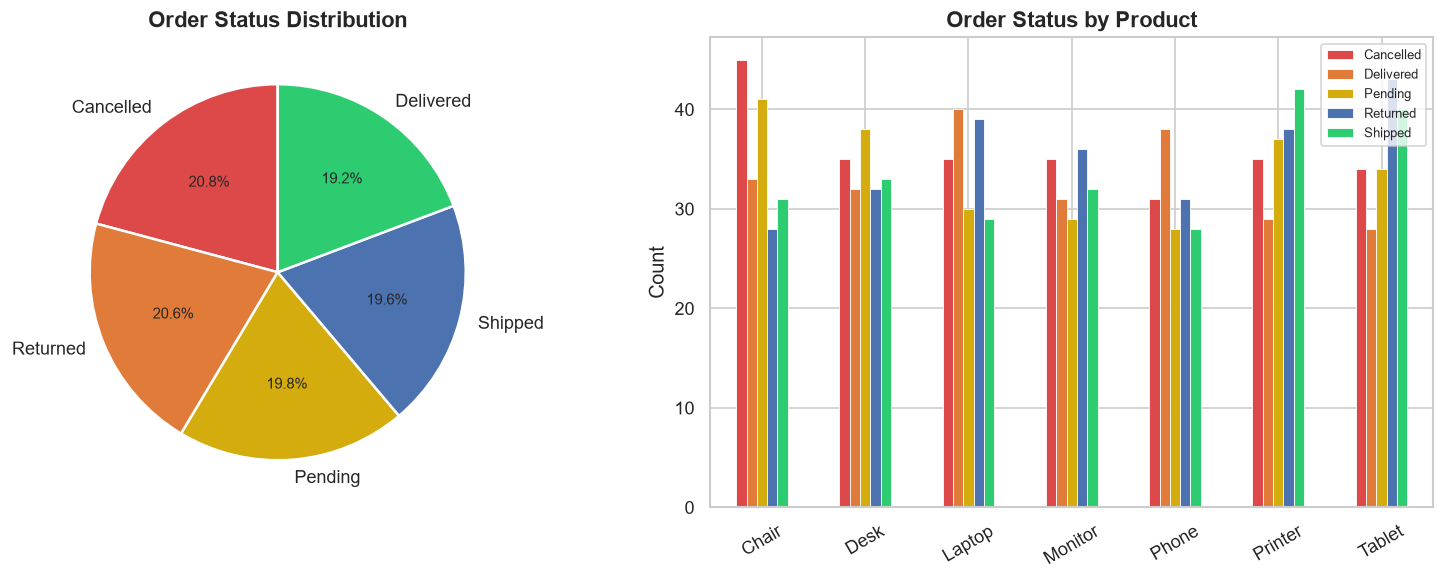

Chart saved: 04_order_status.png


In [9]:
status_counts = df['OrderStatus'].value_counts()
print('Order Status Distribution:')
for s, c in status_counts.items():
    print(f'  {s}: {c} ({c/len(df)*100:.1f}%)')

cancelled_returned = status_counts.get('Cancelled', 0) + status_counts.get('Returned', 0)
print(f'\nCancelled + Returned: {cancelled_returned} ({cancelled_returned/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_colors = ['#DD4949', '#E07B39', '#D4AC0D', '#4C72B0', '#2ECC71']
wedges, texts, autotexts = axes[0].pie(
    status_counts, labels=status_counts.index, autopct='%1.1f%%',
    colors=status_colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Order Status Distribution', fontsize=13, fontweight='bold')

# Status by product (stacked)
status_prod = df.groupby(['Product', 'OrderStatus']).size().unstack(fill_value=0)
status_prod.plot(kind='bar', ax=axes[1], color=status_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Order Status by Product', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('04_order_status.png', bbox_inches='tight')
plt.show()
print('Chart saved: 04_order_status.png')

## 10. Payment Method Analysis

               Avg Order Value  Order Count
PaymentMethod                              
Debit Card             1001.56          232
Online                 1017.22          258
Cash                   1056.04          246
Gift Card              1070.97          230
Credit Card            1127.55          234


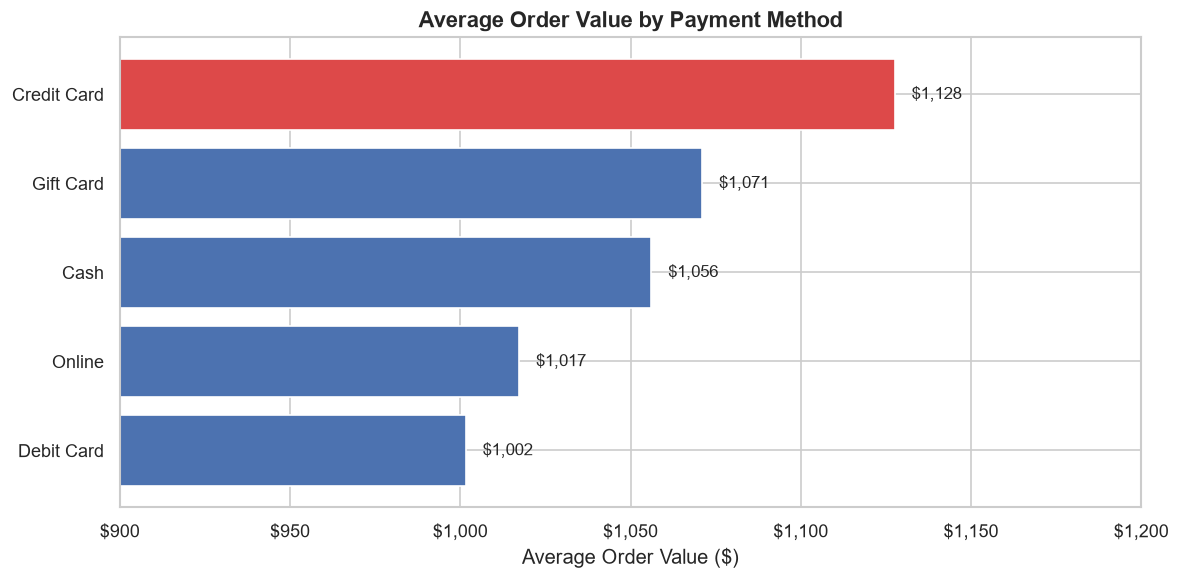

Chart saved: 05_payment_method.png


In [10]:
pay = df.groupby('PaymentMethod')['TotalPrice'].agg(['mean', 'count']).round(2)
pay.columns = ['Avg Order Value', 'Order Count']
pay = pay.sort_values('Avg Order Value', ascending=True)
print(pay)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pay.index, pay['Avg Order Value'],
               color=['#DD4949' if v == pay['Avg Order Value'].max() else '#4C72B0' for v in pay['Avg Order Value']],
               edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)
ax.set_title('Average Order Value by Payment Method', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Order Value ($)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(900, 1200)
plt.tight_layout()
plt.savefig('05_payment_method.png', bbox_inches='tight')
plt.show()
print('Chart saved: 05_payment_method.png')

## 11. Referral Source & Coupon Analysis

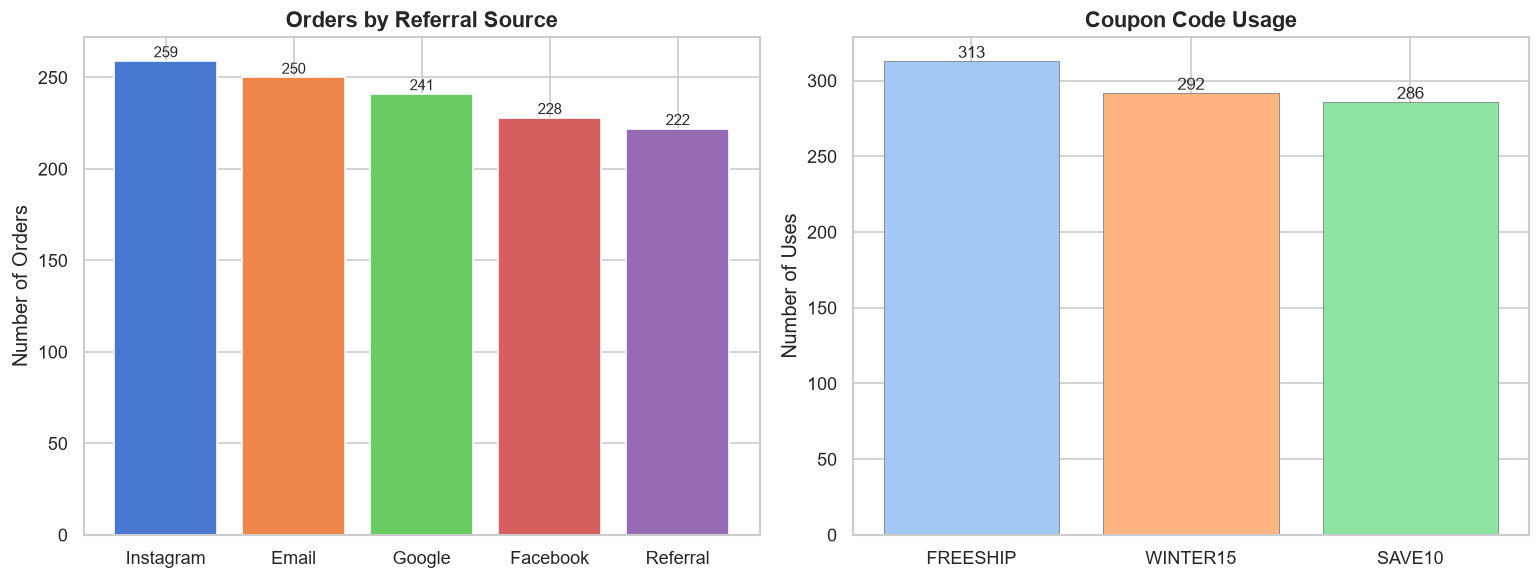

Chart saved: 06_referral_coupon.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Referral source
ref = df['ReferralSource'].value_counts()
axes[0].bar(ref.index, ref.values, color=sns.color_palette('muted', len(ref)), edgecolor='white')
for i, v in enumerate(ref.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)
axes[0].set_title('Orders by Referral Source', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Coupon
coupon = df['CouponCode'].value_counts()
axes[1].bar(coupon.index, coupon.values, color=sns.color_palette('pastel', len(coupon)), edgecolor='gray', linewidth=0.5)
for i, v in enumerate(coupon.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)
axes[1].set_title('Coupon Code Usage', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Uses')

plt.tight_layout()
plt.savefig('06_referral_coupon.png', bbox_inches='tight')
plt.show()
print('Chart saved: 06_referral_coupon.png')

## 12. Correlation Heatmap

Correlation Matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity         1.00       0.01         0.65        0.62
UnitPrice        0.01       1.00         0.00        0.72
ItemsInCart      0.65       0.00         1.00        0.39
TotalPrice       0.62       0.72         0.39        1.00


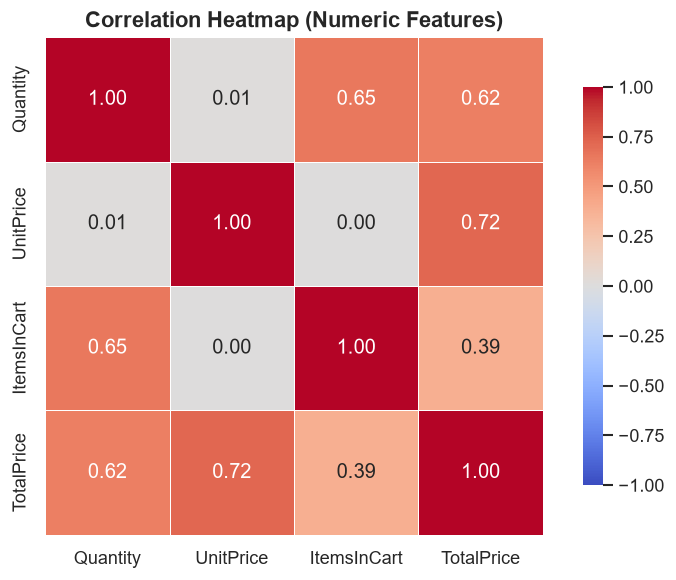

Chart saved: 07_correlation_heatmap.png


In [12]:
numeric_cols = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]
corr = numeric_cols.corr().round(2)
print('Correlation Matrix:')
print(corr)

fig, ax = plt.subplots(figsize=(7, 5))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
import numpy as np
mask_arr = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Chart saved: 07_correlation_heatmap.png')

## 13. Key Observations & Summary

In [13]:
print('=' * 55)
print('   PROJECT 2 — EDA SUMMARY OF KEY OBSERVATIONS')
print('=' * 55)

print(f"""
DATASET OVERVIEW
  Total Orders  : {len(df):,}
  Date Range    : {df['Date'].min().date()} to {df['Date'].max().date()}
  Total Revenue : ${df['TotalPrice'].sum():,.2f}

DESCRIPTIVE STATISTICS
  Mean Order    : ${df['TotalPrice'].mean():,.2f}
  Median Order  : ${df['TotalPrice'].median():,.2f}  (right-skewed distribution)
  Std Deviation : ${df['TotalPrice'].std():,.2f}

OUTLIERS
  8 orders (0.7%) above ${Q3 + 1.5*IQR:,.0f} (IQR method)
  Max order value: ${df['TotalPrice'].max():,.2f}

TRENDS
  Revenue peaked June 2024 (${monthly['TotalPrice'].max():,.0f})
  2023 Revenue: ${df[df.Year==2023]['TotalPrice'].sum():,.0f}
  2024 Revenue: ${df[df.Year==2024]['TotalPrice'].sum():,.0f} (down ~13%)
  2025 (partial): ${df[df.Year==2025]['TotalPrice'].sum():,.0f}

ORDER HEALTH
  Cancelled + Returned: {cancelled_returned} orders ({cancelled_returned/len(df)*100:.1f}%)
  Only Delivered: {status_counts.get('Delivered',0)} ({status_counts.get('Delivered',0)/len(df)*100:.1f}%)

TOP INSIGHTS
  Best payment method : Credit Card (${df[df.PaymentMethod=='Credit Card']['TotalPrice'].mean():,.0f} avg)
  Top referral source : Instagram ({df['ReferralSource'].value_counts().index[0]}, {df['ReferralSource'].value_counts().iloc[0]} orders)
  Most used coupon    : {df['CouponCode'].value_counts().index[0]} ({df['CouponCode'].value_counts().iloc[0]} uses)
  Top product revenue : {prod_rev.index[0]} (${prod_rev['Total Revenue'].iloc[0]:,.0f})
""")

print('Charts saved: 01 through 07 in current folder.')

   PROJECT 2 — EDA SUMMARY OF KEY OBSERVATIONS

DATASET OVERVIEW
  Total Orders  : 1,200
  Date Range    : 2023-01-01 to 2025-06-30
  Total Revenue : $1,264,761.96

DESCRIPTIVE STATISTICS
  Mean Order    : $1,053.97
  Median Order  : $823.62  (right-skewed distribution)
  Std Deviation : $819.86

OUTLIERS
  8 orders (0.7%) above $3,330 (IQR method)
  Max order value: $3,456.40

TRENDS
  Revenue peaked June 2024 ($68,069)
  2023 Revenue: $552,643
  2024 Revenue: $480,236 (down ~13%)
  2025 (partial): $231,883

ORDER HEALTH
  Cancelled + Returned: 497 orders (41.4%)
  Only Delivered: 231 (19.2%)

TOP INSIGHTS
  Best payment method : Credit Card ($1,128 avg)
  Top referral source : Instagram (Instagram, 259 orders)
  Most used coupon    : FREESHIP (313 uses)
  Top product revenue : Chair ($195,620)

Charts saved: 01 through 07 in current folder.
